# Gaussian Kernel from Scratch vs. OpenCV

### 2D Gaussian Kernel Formula:

$$G(x, y) = \frac{1}{2\pi\sigma^2} \exp\left(-\frac{x^2 + y^2}{2\sigma^2}\right)$$

This notebook:

1. Implements a 2-D Gaussian kernel generator from scratch (NumPy only).
2. Computes and displays the $5 \times 5$ kernel for $\sigma = 1$.
3. Builds the same kernel via the outer product of `cv2.getGaussianKernel` with itself and compares numerically.
4. Applies the from-scratch kernel with `cv2.filter2D` and compares against `cv2.GaussianBlur`.
5. Displays original / `filter2D` / `GaussianBlur` side by side and reports Mean Squared Error (MSE).
6. Repeats kernel generation + 3-D surface plots for $\sigma \in \{0.5, 1, 2, 5\}$.


In [4]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

## 1. From-scratch 2-D Gaussian Kernel Generator


In [5]:
def gaussian_kernel_2d(size: int, sigma: float) -> np.ndarray:
    """
    Build a normalized size x size 2-D Gaussian kernel from scratch.

    G(x, y) = (1 / (2*pi*sigma^2)) * exp(-(x^2 + y^2) / (2*sigma^2))
    """
    if size % 2 == 0:
        raise ValueError("size should be odd so the kernel has a center pixel")

    ax = np.arange(size) - (size - 1) / 2.0  # centered coordinates
    xx, yy = np.meshgrid(ax, ax)  # 2-D coordinate grids

    kernel = (1.0 / (2.0 * np.pi * sigma**2)) * np.exp(
        -(xx**2 + yy**2) / (2.0 * sigma**2)
    )

    kernel /= kernel.sum()  # normalize so the kernel sums to 1
    return kernel

## 2. Print the 5x5 Kernel for $\sigma = 1$


In [6]:
kernel_scratch = gaussian_kernel_2d(5, 1.0)
np.set_printoptions(precision=6, suppress=True)

print("From-scratch 5x5 Gaussian kernel, sigma = 1:")
print(kernel_scratch)
print(f"\nSum of kernel entries: {kernel_scratch.sum():.10f}  (should be 1.0)")
print(
    "\nNote: The center cell is largest, values fall off symmetrically in rings, "
    "and the four corners are the smallest entries."
)

From-scratch 5x5 Gaussian kernel, sigma = 1:
[[0.002969 0.013306 0.021938 0.013306 0.002969]
 [0.013306 0.059634 0.09832  0.059634 0.013306]
 [0.021938 0.09832  0.162103 0.09832  0.021938]
 [0.013306 0.059634 0.09832  0.059634 0.013306]
 [0.002969 0.013306 0.021938 0.013306 0.002969]]

Sum of kernel entries: 1.0000000000  (should be 1.0)

Note: The center cell is largest, values fall off symmetrically in rings, and the four corners are the smallest entries.


## 3. Build 2-D Kernel via Outer Product of `cv2.getGaussianKernel`


In [7]:
kernel_1d_cv = cv2.getGaussianKernel(5, 1)  # shape (5, 1)
kernel_2d_cv = kernel_1d_cv @ kernel_1d_cv.T  # outer product -> (5, 5)

print("cv2.getGaussianKernel(5, 1) (1-D):")
print(kernel_1d_cv.ravel())
print("\nOuter product (2-D):")
print(kernel_2d_cv)

matches = np.allclose(kernel_scratch, kernel_2d_cv)
max_abs_diff = np.max(np.abs(kernel_scratch - kernel_2d_cv))
print(f"\nnp.allclose(from-scratch, opencv outer-product) = {matches}")
print(f"Max absolute difference = {max_abs_diff:.3e}")

cv2.getGaussianKernel(5, 1) (1-D):
[0.054489 0.244201 0.40262  0.244201 0.054489]

Outer product (2-D):
[[0.002969 0.013306 0.021938 0.013306 0.002969]
 [0.013306 0.059634 0.09832  0.059634 0.013306]
 [0.021938 0.09832  0.162103 0.09832  0.021938]
 [0.013306 0.059634 0.09832  0.059634 0.013306]
 [0.002969 0.013306 0.021938 0.013306 0.002969]]

np.allclose(from-scratch, opencv outer-product) = True
Max absolute difference = 1.388e-17


## 4. Load Grayscale Test Image & Apply Filters


In [17]:
def load_grayscale_image(path: str = "images/image1.jpg") -> np.ndarray:
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (64, 64), interpolation=cv2.INTER_AREA)
    return img


img = load_grayscale_image("images/image1.jpg")

result_filter2d = cv2.filter2D(
    img, ddepth=-1, kernel=kernel_scratch, borderType=cv2.BORDER_REFLECT101
)
result_gaussianblur = cv2.GaussianBlur(img, (5, 5), 1)

## 5. Side-by-Side Display & MSE Comparison ($\sigma = 1$)


MSE(filter2D result, GaussianBlur result) = 0.025635


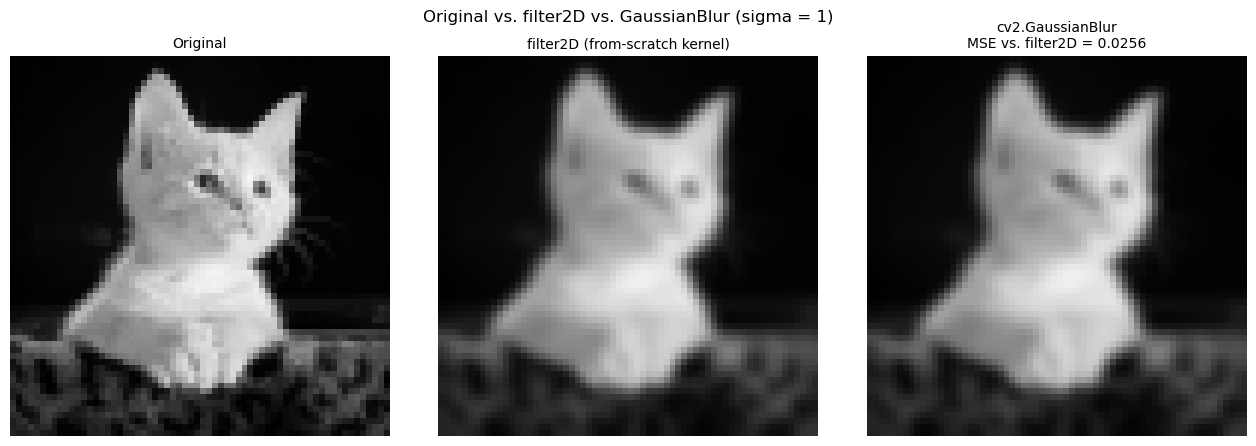

In [18]:
mse = float(
    np.mean(
        (result_filter2d.astype(np.float64) - result_gaussianblur.astype(np.float64))
        ** 2
    )
)
print(f"MSE(filter2D result, GaussianBlur result) = {mse:.6f}")

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
titles = [
    "Original",
    "filter2D (from-scratch kernel)",
    f"cv2.GaussianBlur\nMSE vs. filter2D = {mse:.4f}",
]
images = [img, result_filter2d, result_gaussianblur]

for ax, title, im in zip(axes, titles, images):
    ax.imshow(im, cmap="gray", vmin=0, vmax=255)
    ax.set_title(title, fontsize=10)
    ax.axis("off")

fig.suptitle("Original vs. filter2D vs. GaussianBlur (sigma = 1)")
fig.tight_layout()
plt.show()

## 6. Kernel Shape Across $\sigma = 0.5, 1, 2, 5$ with 3-D Surface Plots


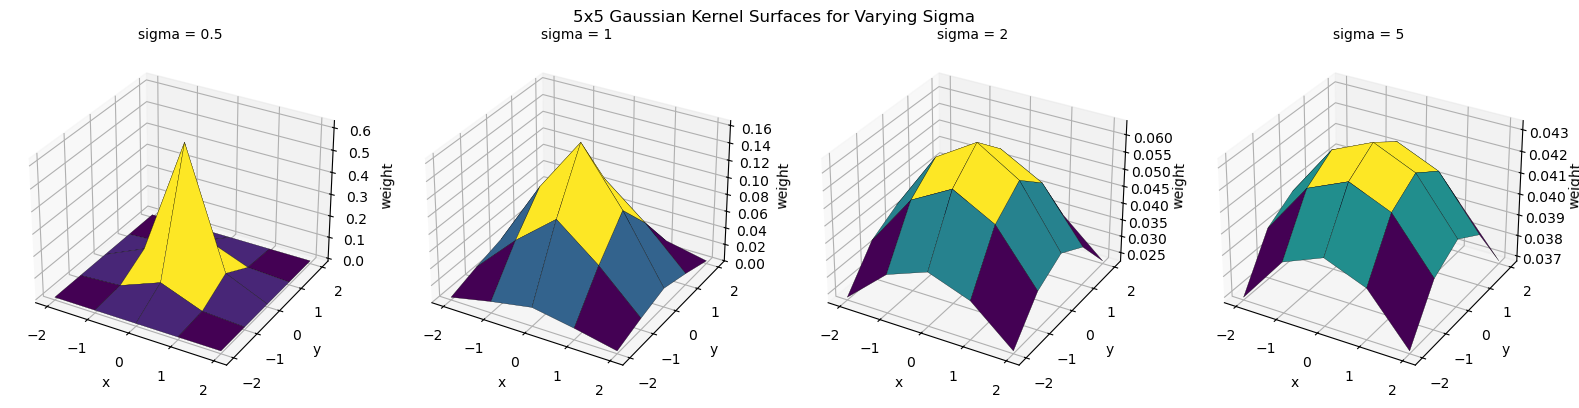


Kernel center-vs-corner weight, by sigma:
  sigma=0.5  center=0.61869  corner=0.00000  ratio(center/corner)=8886110.52
  sigma=1    center=0.16210  corner=0.00297  ratio(center/corner)=54.60
  sigma=2    center=0.06319  corner=0.02325  ratio(center/corner)=2.72
  sigma=5    center=0.04328  corner=0.03688  ratio(center/corner)=1.17


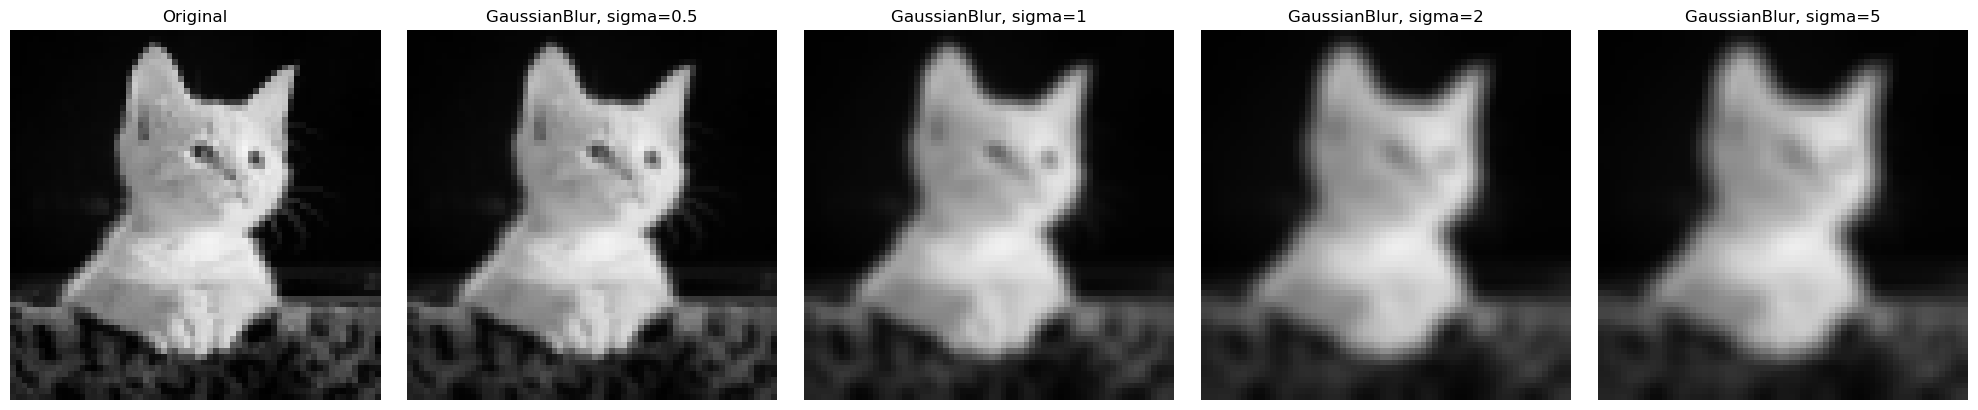

In [19]:
sigmas = [0.5, 1, 2, 5]
size = 5

fig2 = plt.figure(figsize=(16, 4))
ax_coords = np.arange(size) - (size - 1) / 2.0
X, Y = np.meshgrid(ax_coords, ax_coords)

kernels = {}
for i, s in enumerate(sigmas):
    k = gaussian_kernel_2d(size, s)
    kernels[s] = k

    ax3d = fig2.add_subplot(1, len(sigmas), i + 1, projection="3d")
    ax3d.plot_surface(X, Y, k, cmap="viridis", edgecolor="k", linewidth=0.2)
    ax3d.set_title(f"sigma = {s}", fontsize=10)
    ax3d.set_xlabel("x")
    ax3d.set_ylabel("y")
    ax3d.set_zlabel("weight")

fig2.suptitle("5x5 Gaussian Kernel Surfaces for Varying Sigma")
fig2.tight_layout()
plt.show()

print("\nKernel center-vs-corner weight, by sigma:")
for s in sigmas:
    k = kernels[s]
    center = k[size // 2, size // 2]
    corner = k[0, 0]
    print(
        f"  sigma={s:<4} center={center:.5f}  corner={corner:.5f}  "
        f"ratio(center/corner)={center / corner:.2f}"
    )

# Visual comparison of blurred images for each sigma
fig3, axes3 = plt.subplots(1, len(sigmas) + 1, figsize=(4 * (len(sigmas) + 1), 4))
axes3[0].imshow(img, cmap="gray", vmin=0, vmax=255)
axes3[0].set_title("Original")
axes3[0].axis("off")
for ax, s in zip(axes3[1:], sigmas):
    blurred = cv2.GaussianBlur(img, (5, 5), s)
    ax.imshow(blurred, cmap="gray", vmin=0, vmax=255)
    ax.set_title(f"GaussianBlur, sigma={s}")
    ax.axis("off")
fig3.tight_layout()
plt.show()